<a href="https://colab.research.google.com/github/HannahShaw21/Public-Repo-4-Hannah/blob/main/HW3_Hannah_Shaw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### AI policy: not allowed except when the question says "you can use AI for this". Please turn-off the automatic completion support function (AI support) in your notebook environment.

In [3]:
from sklearn.datasets import fetch_openml

# MNIST 데이터 불러오기
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X, y = mnist["data"], mnist["target"]
y = y.astype(int)  # 문자열 → 숫자 변환

print("Data shape:", X.shape)   # (70000, 784)
print("Label shape:", y.shape)  # (70000,)

Data shape: (70000, 784)
Label shape: (70000,)


In [4]:
X,y = X[:7000], y[:7000]
print("Data shape:", X.shape)   # (70000, 784)
print("Label shape:", y.shape)  # (70000,)

Data shape: (7000, 784)
Label shape: (7000,)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def show_mnist(images, labels=None, ncols=5, figsize=(10, 10)):
    """
    Visualize one or more MNIST images (28x28).

    Parameters
    ----------
    images : np.ndarray or list
        Either a single image vector of shape (784,), or multiple images of shape (N, 784).
    labels : list or np.ndarray, optional
        Labels corresponding to the images. If provided, will be shown as titles.
    ncols : int, optional
        Number of images per row (default=5).
    figsize : tuple, optional
        Size of the whole matplotlib figure (default=(10,10)).
    """
    # Convert input to numpy array
    images = np.array(images)
    # If only one image is given (784,), reshape into (1, 784)
    if images.ndim == 1:
        images = images.reshape(1, -1)

    n = len(images)                          # number of images
    nrows = int(np.ceil(n / ncols))          # number of rows needed

    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        if labels is not None:
            plt.title(str(labels[i]))
    plt.tight_layout()
    plt.show()

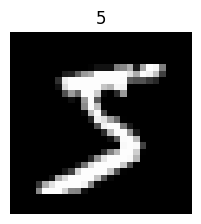

In [6]:
show_mnist(X[0], labels=[y[0]])

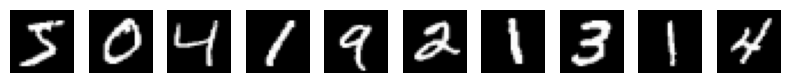

In [7]:
# Show 10 digits in a grid
show_mnist(X[:10], labels=None, ncols=10, figsize=(8,4))

In [8]:
x0 = X[0] # I define x0 as the first MNIST sample

## Q1. Nearest Neighbor Analysis

1) Find the 10 nearest neighbors of x0

2) What are their labels?

3) Plot x0 and its 10 neighbors. Do they look similar? (use above show_mnist code)

4) Find the 50 nearest neighbors of x0. Do they look similar to x0? Discuss.

5) Draw a bar plot of their label distribution.


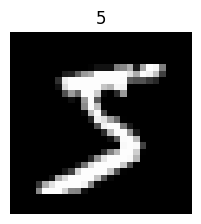

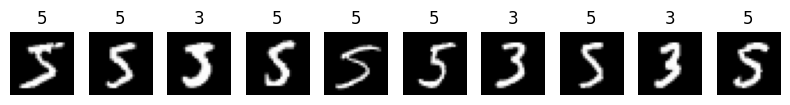

In [9]:
from scipy.spatial import KDTree

kdtree = KDTree(X) #Build the KD tree using our image array
distances, indices = kdtree.query(x0, k=10) #x0 is the query point
nearest_neighbors = X[indices] #gives the actual coordinates of the 10 nearest points.
show_mnist(X[0], labels=[y[0]]) #plot x0 and label
show_mnist(X[indices], labels=y[indices], ncols=10, figsize=(8,4)) #plot its 10 neighbors with labels

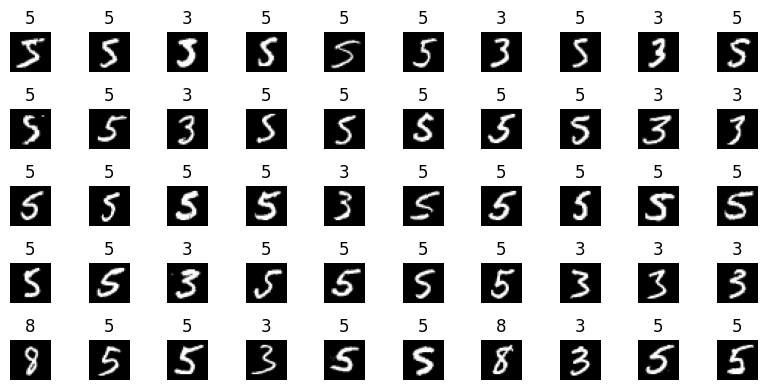

In [10]:
distances, indices = kdtree.query(x0, k=50) #Find the 50 nearest neighbors
nearest_neighbors = X[indices] #gives the actual coordinates of the 50 nearest points.
show_mnist(X[indices], labels=y[indices], ncols=10, figsize=(8,4)) #plot its 50 neighbors with labels

The majority of the 50 nearest neighbors look similar to x0. For the 5s, they share both the same label and visual similiarity. For the 3s, while not all of them resemble x0, enough of them do that the rest of the 3s likely were included just for sharing the same label. As for the 8s, while they have the least amount of resemblance to x0 out of the 50 nearest neighbors, x0 does share some similarity to half of an 8 (that is, if you were writing an 8 and stopped halfway, the result would look like x0).

Text(0.5, 1.0, 'Label distribution of 50 nearest neighbors of x0')

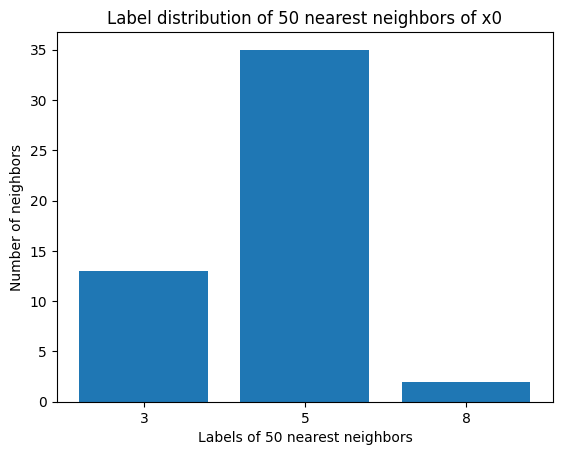

In [11]:
import matplotlib.pyplot as plt

label_names = ["3", "5", "8"]
label_counts = [13, 35, 2]

plt.bar(label_names, label_counts)
plt.xlabel('Labels of 50 nearest neighbors')
plt.ylabel('Number of neighbors')
plt.title('Label distribution of 50 nearest neighbors of x0')

## Q2. KNN with Hold-out

1. Split data into 50% train and 50% test dataset for training (one hold-out split).

2. Apply K-Nearest Neighbors (KNN) classification for various values of k.

3. Plot the accuracy vs. k curve. (You may use AI tools to generate the plots.)

In [12]:
import numpy as np                                  # default, basic python package
import pandas as pd                                 # default, basic python package
import matplotlib.pyplot as plt                     # produces plots
from scipy.stats import gaussian_kde                # produces density curves

import random                                       # generates random numbers
from sklearn.utils import check_random_state        # generates random numbers (alternative method)

from sklearn.datasets import fetch_openml           # contains Boston dataset
from sklearn.neighbors import KNeighborsRegressor   # performs KNN Regression Modeling
#from sklearn.preprocessing import StandardScaler    # performs standardization/ normalizes data
from sklearn.pipeline import make_pipeline          # _
from sklearn.model_selection import (
    train_test_split,                               # performs holdout method (i.e., SRSWOR, similar to base R)
    ShuffleSplit,                                   # performs holdout method (similar to rsample)
    StratifiedShuffleSplit,                         # performs holdout method (similar to caret::createDataPartition)
    KFold,                                          # performs V-fold CV
    cross_val_score,                                # performs computed mse scores
    cross_validate,                                 # performs CV
    GridSearchCV,                                   # _
    LeaveOneOut                                     # performs LOOCV
)
from sklearn.ensemble import BaggingRegressor       # performs bootstrapping
from sklearn.metrics import make_scorer, mean_squared_error      # performs _ & computes mse scores

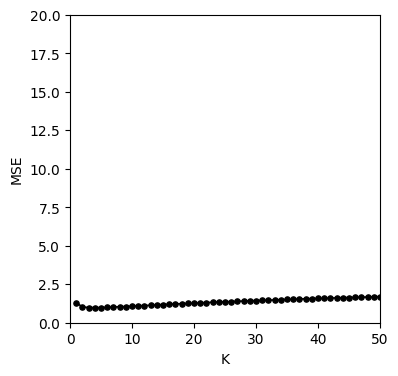

In [15]:
n = len(X)
split = n // 2
#train/test sets (50/50 holdout)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Grid search over K = 1..50
kgrid = list(range(1, 51))
mse = np.empty(len(kgrid), dtype=float)

for i, k in enumerate(kgrid):
  knn = KNeighborsRegressor(n_neighbors=k)
  knn.fit(X_train, y_train)
  pred = knn.predict(X_test)
  mse[i] = mean_squared_error(y_test, pred)

# Optimal K (min test MSE)
k_opt = kgrid[int(np.argmin(mse))]
mse_opt = mse.min()

# Plots
fig, ax = plt.subplots(figsize=(4, 4))                 # defines plot framework
ax.plot(kgrid, mse, "-", color="black", lw=1.2, zorder=1)  # connecting line
ax.scatter(kgrid, mse, s=14, c="black")                    # points only
ax.set_xlabel("K")        # labels name to x-axis
ax.set_ylabel("MSE")      # labels name to y-axis
ax.set_xlim(0, 50)       # controls boundaries to x-axis
ax.set_ylim(0, 20)       # controls boundaries to y-axis
ax.grid(False)            # Removes grid lines

## 3. KNN with Cross-Validation

1. Repeat the above experiment using 5-fold cross-validation instead of a single hold-out split.

2. For each k, compute the average accuracy across the 5 folds.

3. Plot the mean accuracy vs. k curve. (You may use AI tools to generate the plots.)

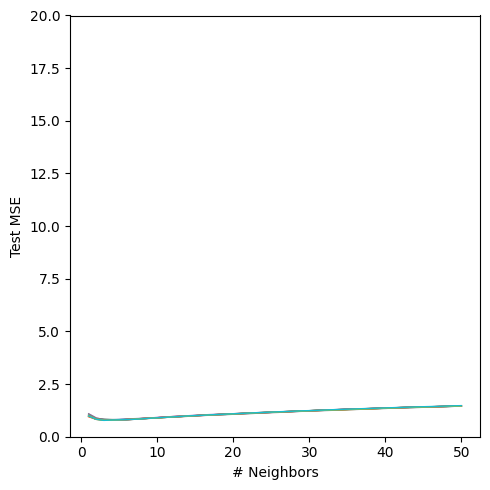

In [16]:
rng = 100
repeats = 10
k_values = np.arange(1, 51)   # 1..50 neighbors
mse_curves = np.zeros((repeats, len(k_values)))

for r in range(repeats):
    cv5 = KFold(n_splits=5, shuffle=True, random_state=rng + r)  # new shuffle each repeat
    for i, k in enumerate(k_values):
        model = KNeighborsRegressor(n_neighbors=k)
        # mean test MSE over the 5 folds for this repeat
        fold_mse = -cross_val_score(model, X, y,
                                    scoring="neg_mean_squared_error",
                                    cv=cv5, n_jobs=-1)
        mse_curves[r, i] = fold_mse.mean()

# ---- Plot to match the style of your figure ----
plt.figure(figsize=(5, 5))
for r in range(repeats):
    plt.plot(k_values, mse_curves[r], linewidth=1)  # default black lines

plt.xlabel("# Neighbors")
plt.ylabel("Test MSE")
plt.ylim(0, 20)                 # matches the axis range in your screenshot
plt.tight_layout()
plt.show()